## PDP and Joint-PDP via glex

Implements `glex_xy(model, x_explain, x_background)` by connecting glex's internal
pieces, allowing **distinct explain data** and **background data**.

Derives PDP and Joint-PDP from the functional ANOVA decomposition:
- **PDP** of feature $i$: $m_{\emptyset} + m_{\{i\}}(x)$
- **J-PDP** of features $i,j$: $m_{\emptyset} + m_{\{i\}} + m_{\{j\}} + m_{\{i,j\}}$

Both are verified against the naive estimator (fix-feature, average over background).

In [1]:
install.packages(c('xgboost', 'ggplot2', 'dplyr', 'data.table', 'remotes'),
                 repos = 'https://cloud.r-project.org', quiet = TRUE)
remotes::install_github('PlantedML/glex', quiet = TRUE)

Installing 12 packages: rlang, glue, cli, vctrs, cpp11, S7, iterators, backports, Rcpp, scico, foreach, checkmate



In [2]:
library(xgboost)
library(glex)
library(ggplot2)
library(dplyr)
library(data.table)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




## `glex_xy`: glex with separate background data

Standard `glex()` samples background from `x` itself (see `glex.R:463`).
Internally, the C++ kernel `explainTreeFastPDBitmask` already accepts separate
`x_explain` and `x_background` — the R wrapper just hardwires them to the same matrix.

We bypass this by calling `glex:::tree_fun_emp_fastPD` directly in the tree loop,
passing our own `x_background`. Feature numbering and subset enumeration are taken
verbatim from `calc_components`.

In [3]:
glex_xy <- function(model, x_explain, x_background, max_interaction = NULL) {
  if (!is.matrix(x_explain))    x_explain    <- as.matrix(x_explain)
  if (!is.matrix(x_background)) x_background <- as.matrix(x_background)
  if (is.null(max_interaction))  max_interaction <- 9999

  # ---- Prepare tree table (mirrors glex.xgb.Booster) ----
  trees <- xgboost::xgb.model.dt.tree(model = model, use_int_id = TRUE)
  trees$Type <- '<'

  # 1-indexed feature numbering: 0 = leaf, 1..p = features
  unique_feats <- unique(trees$Feature)
  unique_feats <- unique_feats[unique_feats != 'Leaf']
  if (suppressWarnings(all(!is.na(as.integer(unique_feats))))) {
    trees[Feature == 'Leaf', Feature_num := 0L]
    trees[Feature != 'Leaf', Feature_num := as.integer(Feature) + 1L]
  } else {
    trees[, Feature_num := as.integer(
      factor(Feature, levels = c('Leaf', colnames(x_explain)))) - 1L]
  }

  # ---- Enumerate all feature subsets to explain (union across trees) ----
  all_S <- unique(do.call(c, lapply(0:max(trees$Tree), function(t) {
    feats <- trees[Tree == t & Feature_num > 0, sort(unique(Feature_num))]
    glex:::get_all_subsets_cpp(feats, max_interaction)
  })))

  # ---- Sum per-tree contributions using x_background as reference ----
  m_all     <- matrix(0, nrow = nrow(x_explain), ncol = length(all_S))
  col_names <- NULL
  for (t in 0:max(trees$Tree)) {
    m_tree <- glex:::tree_fun_emp_fastPD(
      t, trees, x_explain, x_background, all_S, max_interaction
    )
    if (is.null(col_names)) col_names <- colnames(m_tree)
    m_all <- m_all + m_tree
  }
  colnames(m_all) <- col_names

  base_score <- glex:::get_xgb_base_score(model)

  list(
    m         = data.table::setDT(as.data.frame(m_all[, -1])),
    intercept = unique(m_all[, 1]) + base_score,
    x         = data.table::setDT(as.data.frame(x_explain))
  )
}

## PDP and Joint-PDP from glex output

Under the independence assumption of the functional ANOVA:

$$\operatorname{PDP}_i(v) = \mathbb{E}_{\mathbf{y}_{-i}}[f(v, \mathbf{y}_{-i})] = m_{\emptyset} + m_{\{i\}}(v)$$

The higher-order terms vanish because the centering property of the ANOVA components
makes $\mathbb{E}[m_{\{i,j\}}(v, Y_j)] = 0$ for any fixed $v$.

Similarly for the Joint-PDP:
$$\operatorname{JPDP}_{ij}(v_i, v_j) = m_{\emptyset} + m_{\{i\}}(v_i) + m_{\{j\}}(v_j) + m_{\{i,j\}}(v_i, v_j)$$

In [4]:
# PDP evaluated at each x_explain row's value of `feature`
compute_pdp <- function(glex_result, feature) {
  m_i <- glex_result$m[[feature]]
  if (is.null(m_i)) stop('Feature not found in glex result: ', feature)
  data.frame(
    x_val = glex_result$x[[feature]],
    pdp   = glex_result$intercept + m_i
  )
}

# Joint-PDP evaluated at each x_explain row's (feature_i, feature_j) values
compute_jpdp <- function(glex_result, feature_i, feature_j) {
  m_i     <- glex_result$m[[feature_i]]
  m_j     <- glex_result$m[[feature_j]]
  int_col <- paste(sort(c(feature_i, feature_j)), collapse = ':')
  m_ij    <- glex_result$m[[int_col]]
  if (is.null(m_i))  stop('Feature not found: ', feature_i)
  if (is.null(m_j))  stop('Feature not found: ', feature_j)
  if (is.null(m_ij)) stop('Interaction not found: ', int_col)
  data.frame(
    x_i  = glex_result$x[[feature_i]],
    x_j  = glex_result$x[[feature_j]],
    jpdp = glex_result$intercept + m_i + m_j + m_ij
  )
}

## Naive estimators for verification

For each row of `x_explain`, fix the target feature(s) to that row's values,
predict on all `x_background` rows, and take the mean.
This is the direct Monte Carlo estimate of the partial dependence.

In [5]:
naive_pdp <- function(model, x_explain, x_background, feature) {
  sapply(seq_len(nrow(x_explain)), function(i) {
    x_mod            <- x_background
    x_mod[, feature] <- x_explain[i, feature]
    mean(predict(model, x_mod))
  })
}

naive_jpdp <- function(model, x_explain, x_background, feature_i, feature_j) {
  sapply(seq_len(nrow(x_explain)), function(i) {
    x_mod              <- x_background
    x_mod[, feature_i] <- x_explain[i, feature_i]
    x_mod[, feature_j] <- x_explain[i, feature_j]
    mean(predict(model, x_mod))
  })
}

## Data and model

Synthetic data with known structure:
$$y = x_1^2 + x_2 x_3 + 0.5\, x_4 + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 0.3^2)$$

Three disjoint splits:
- `X_train` (1200 rows): train the model
- `X_bg` (400 rows): background distribution for glex and naive estimator
- `X_exp` (100 rows): the points to explain (small so naive is fast)

In [7]:
set.seed(42)
n_total <- 2000
p       <- 8
X       <- matrix(rnorm(n_total * p), n_total, p)
colnames(X) <- paste0('x', 1:p)
y <- X[,'x1']^2 + X[,'x2'] * X[,'x3'] + 0.5 * X[,'x4'] + rnorm(n_total, sd = 0.3)

X_train <- X[1:1200, ];    y_train <- y[1:1200]
X_bg    <- X[1201:1600, ]  # 400 background samples
X_exp   <- X[1601:1700, ]  # 100 explain points

model <- xgboost(
  x         = X_train,
  y         = y_train,
  max_depth = 4,
  eta       = 0.1,
  objective = 'reg:squarederror',
  nrounds   = 100,
  verbose   = 0
)
cat('Model trained.\n')

Warning message in throw_err_or_depr_msg("Passed unrecognized parameters: ", paste(head(names_unrecognized), :
“Passed unrecognized parameters: verbose. This warning will become an error in a future version.”
Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
“Parameter 'eta' has been renamed to 'learning_rate'. This warning will become an error in a future version.”


Model trained.


## Sanity check: glex_xy(x, x) == glex(x)

When explain = background, `glex_xy` should match standard `glex()`.

In [8]:
# Use a small slice so both calls are fast
X_check <- X_bg[1:50, ]

gl_std <- glex(model, X_check)          # standard glex: background = explain = X_check
gl_xy  <- glex_xy(model, X_check, X_check)  # our function with same data for both

# Compare intercepts
cat(sprintf('Intercept  glex: %.6f   glex_xy: %.6f\n', gl_std$intercept, gl_xy$intercept))

# Compare m values for x1
diff_x1 <- max(abs(gl_std$m$x1 - gl_xy$m$x1))
cat(sprintf('Max |m[x1] difference|: %.2e  (should be near 0)\n', diff_x1))

Intercept  glex: 0.904959   glex_xy: 0.904959
Max |m[x1] difference|: 0.00e+00  (should be near 0)


## Run glex_xy with separate background

In [9]:
gl <- glex_xy(model, X_exp, X_bg, max_interaction = 2)

cat('Intercept:', gl$intercept, '\n')
cat('Number of m components:', ncol(gl$m), '\n')
cat('Component names (first 12):', head(names(gl$m), 12), '\n')

Intercept: 0.9472183 
Number of m components: 36 
Component names (first 12): x1 x1:x3 x1:x4 x1:x5 x3 x3:x4 x3:x5 x4 x4:x5 x5 x1:x8 x4:x8 


## Verification: PDP of x1

glex: `intercept + m[{x1}]` vs. naive fix-and-average.  
Points should lie on the diagonal; RMSE should be near zero.

PDP RMSE (glex_xy vs naive): 0.000000


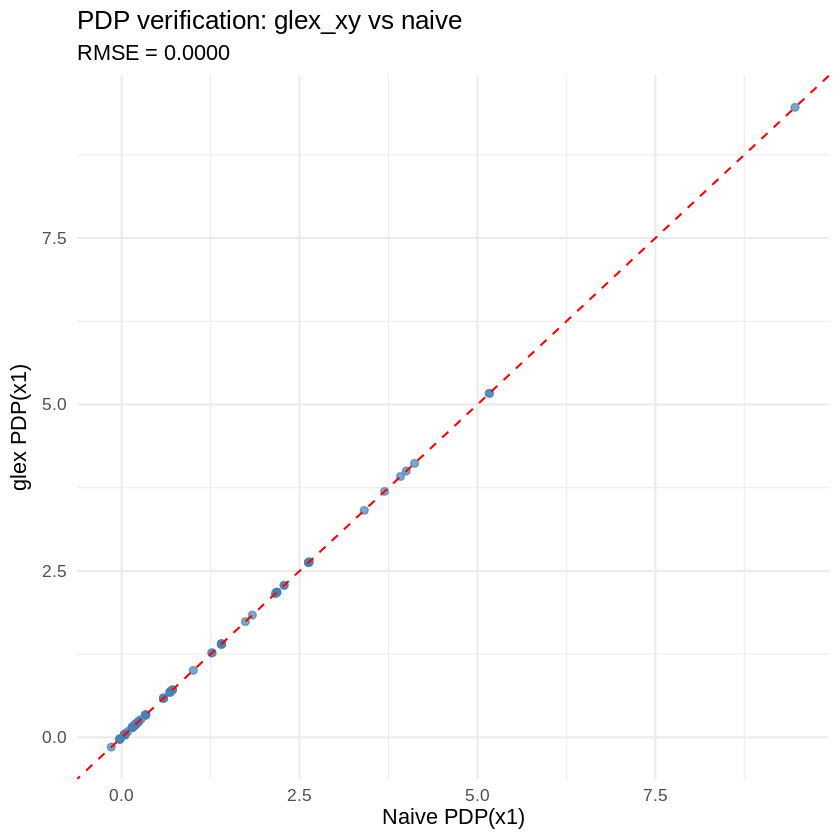

In [10]:
pdp_gl    <- compute_pdp(gl, 'x1')
pdp_naive <- naive_pdp(model, X_exp, X_bg, 'x1')

rmse_pdp <- sqrt(mean((pdp_gl$pdp - pdp_naive)^2))
cat(sprintf('PDP RMSE (glex_xy vs naive): %.6f\n', rmse_pdp))

ggplot(data.frame(glex = pdp_gl$pdp, naive = pdp_naive), aes(naive, glex)) +
  geom_point(alpha = 0.7, color = 'steelblue') +
  geom_abline(slope = 1, intercept = 0, color = 'red', linetype = 'dashed') +
  labs(
    title    = 'PDP verification: glex_xy vs naive',
    subtitle = sprintf('RMSE = %.4f', rmse_pdp),
    x = 'Naive PDP(x1)', y = 'glex PDP(x1)'
  ) +
  theme_minimal(base_size = 13)

## Verification: Joint-PDP of x2 and x3

glex: `intercept + m[{x2}] + m[{x3}] + m[{x2,x3}]` vs naive.

Joint-PDP RMSE (glex_xy vs naive): 0.000000


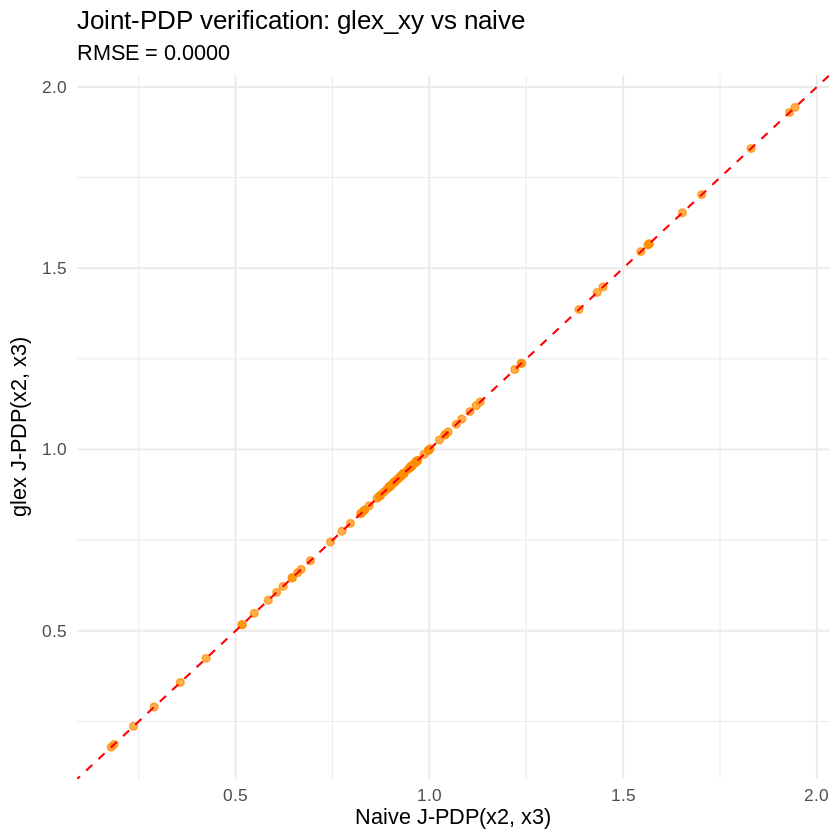

In [11]:
jpdp_gl    <- compute_jpdp(gl, 'x2', 'x3')
jpdp_naive <- naive_jpdp(model, X_exp, X_bg, 'x2', 'x3')

rmse_jpdp <- sqrt(mean((jpdp_gl$jpdp - jpdp_naive)^2))
cat(sprintf('Joint-PDP RMSE (glex_xy vs naive): %.6f\n', rmse_jpdp))

ggplot(data.frame(glex = jpdp_gl$jpdp, naive = jpdp_naive), aes(naive, glex)) +
  geom_point(alpha = 0.7, color = 'darkorange') +
  geom_abline(slope = 1, intercept = 0, color = 'red', linetype = 'dashed') +
  labs(
    title    = 'Joint-PDP verification: glex_xy vs naive',
    subtitle = sprintf('RMSE = %.4f', rmse_jpdp),
    x = 'Naive J-PDP(x2, x3)', y = 'glex J-PDP(x2, x3)'
  ) +
  theme_minimal(base_size = 13)

## PDP curve: marginal effect of x1

True marginal: $\mathbb{E}[y | x_1 = v] \approx v^2 + \text{const}$, so the curve should be roughly quadratic.

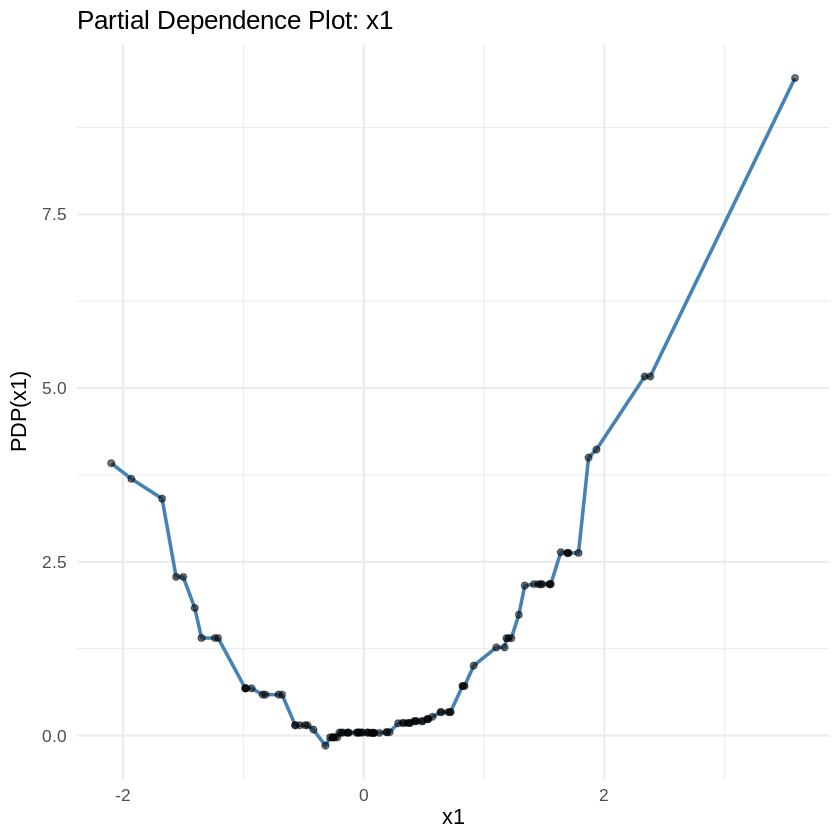

In [12]:
pdp_sorted <- pdp_gl[order(pdp_gl$x_val), ]

ggplot(pdp_sorted, aes(x_val, pdp)) +
  geom_line(color = 'steelblue', linewidth = 1) +
  geom_point(alpha = 0.5, size = 1.5) +
  labs(
    title = 'Partial Dependence Plot: x1',
    x = 'x1', y = 'PDP(x1)'
  ) +
  theme_minimal(base_size = 13)

## Joint-PDP heatmap: x2 x x3

True interaction is $x_2 x_3$, so the heatmap should show a diagonal sign-change pattern
(positive where $x_2, x_3$ have the same sign; negative where they differ).

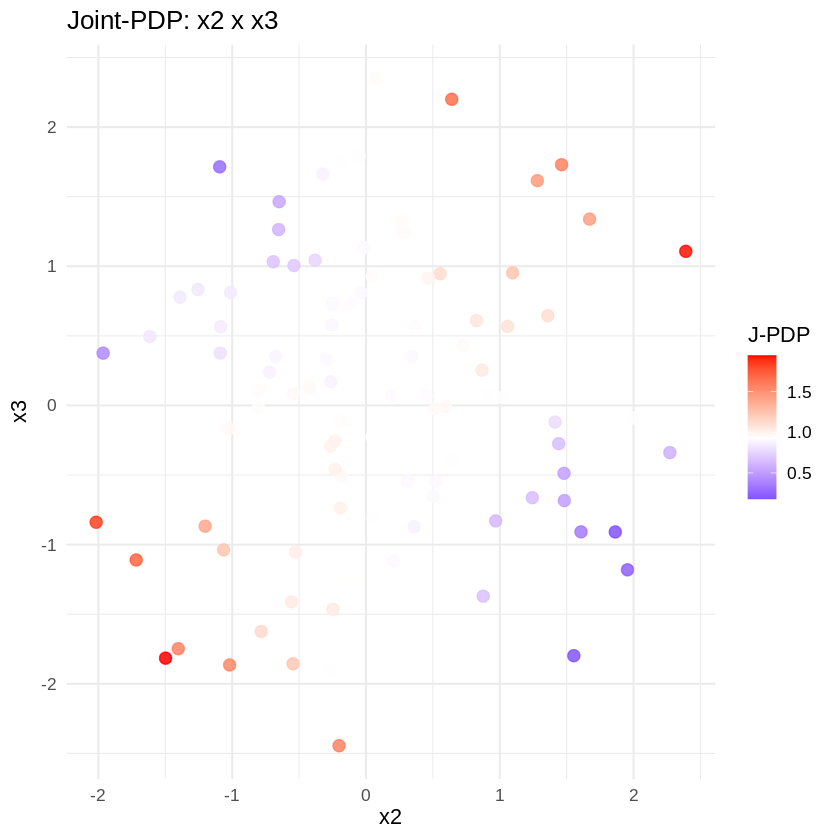

In [13]:
mid_val <- median(jpdp_gl$jpdp)

ggplot(jpdp_gl, aes(x_i, x_j, color = jpdp)) +
  geom_point(size = 3, alpha = 0.85) +
  scale_color_gradient2(
    low      = 'blue',
    mid      = 'white',
    high     = 'red',
    midpoint = mid_val
  ) +
  labs(
    title = 'Joint-PDP: x2 x x3',
    x = 'x2', y = 'x3', color = 'J-PDP'
  ) +
  theme_minimal(base_size = 13)